# NYC Flights Data Cleaning and Exploration

## Project Overview
This notebook focuses on cleaning and exploring the NYC Flights dataset.
The main goals are:
- Understand the structure of the dataset
- Handle missing values and duplicates
- Explore delays and flight patterns
- Extract useful insights from the data

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\Dell\Downloads\nycflights.csv")
df.head()

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance,hour,minute
0,2013,6,30,940,15,1216,-4,VX,N626VA,407,JFK,LAX,313,2475,9,40
1,2013,5,7,1657,-3,2104,10,DL,N3760C,329,JFK,SJU,216,1598,16,57
2,2013,12,8,859,-1,1238,11,DL,N712TW,422,JFK,LAX,376,2475,8,59
3,2013,5,14,1841,-4,2122,-34,DL,N914DL,2391,JFK,TPA,135,1005,18,41
4,2013,7,21,1102,-3,1230,-8,9E,N823AY,3652,LGA,ORF,50,296,11,2


In [48]:
print(df.columns)
print("="*80)
df.info()

Index(['year', 'month', 'day', 'dep_time', 'dep_delay', 'arr_time',
       'arr_delay', 'carrier', 'tailnum', 'flight', 'origin', 'dest',
       'air_time', 'distance', 'hour', 'minute'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32735 entries, 0 to 32734
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   year       32735 non-null  int64 
 1   month      32735 non-null  int64 
 2   day        32735 non-null  int64 
 3   dep_time   32735 non-null  int64 
 4   dep_delay  32735 non-null  int64 
 5   arr_time   32735 non-null  int64 
 6   arr_delay  32735 non-null  int64 
 7   carrier    32735 non-null  object
 8   tailnum    32735 non-null  object
 9   flight     32735 non-null  int64 
 10  origin     32735 non-null  object
 11  dest       32735 non-null  object
 12  air_time   32735 non-null  int64 
 13  distance   32735 non-null  int64 
 14  hour       32735 non-null  int64 
 15  minute     32

## Initial Data Inspection
In this section, we examine the dataset structure, columns, and data types.

In [55]:
df.describe()

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,flight,air_time,distance,hour,minute
count,32735.0,32735.000000,32735.000000,32735.000000,32735.000000,32735.000000,32735.000000,32735.000000,32735.000000,32735.000000,32735.000000,32735.000000
mean,2013.0,6.576081,15.777241,1349.265862,12.705147,1502.907408,7.100810,1947.796579,150.441912,1046.244051,13.174462,31.819704
std,0.0,3.413269,8.793983,488.690994,40.407426,532.412363,44.687329,1621.204308,93.527663,733.681907,4.899536,18.226010
min,2013.0,1.000000,1.000000,1.000000,-21.000000,1.000000,-73.000000,1.000000,22.000000,94.000000,0.000000,0.000000
25%,2013.0,4.000000,8.000000,908.000000,-5.000000,1106.000000,-17.000000,550.000000,82.000000,502.000000,9.000000,16.000000
50%,2013.0,7.000000,16.000000,1358.000000,-2.000000,1537.000000,-5.000000,1473.000000,129.000000,888.000000,13.000000,32.000000
75%,2013.0,10.000000,23.000000,1744.000000,11.000000,1939.000000,14.000000,3416.000000,191.000000,1391.000000,17.000000,49.000000
max,2013.0,12.000000,31.000000,2400.000000,1301.000000,2400.000000,1272.000000,6181.000000,686.000000,4983.000000,24.000000,59.000000


In [57]:
df.describe(include='object')

,carrier,tailnum,origin,dest
count,32735,32735,32735,32735
unique,16,3490,3,102
top,UA,N725MQ,EWR,ATL
freq,5770,59,11771,1653


In [59]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Series([], dtype: int64)

In [63]:
df.duplicated().sum()

0

## Data Cleaning
In this section, missing values, duplicates, and incorrect data types are handled.

In [68]:
df.head()

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance,hour,minute
0,2013,6,30,940,15,1216,-4,VX,N626VA,407,JFK,LAX,313,2475,9,40
1,2013,5,7,1657,-3,2104,10,DL,N3760C,329,JFK,SJU,216,1598,16,57
2,2013,12,8,859,-1,1238,11,DL,N712TW,422,JFK,LAX,376,2475,8,59
3,2013,5,14,1841,-4,2122,-34,DL,N914DL,2391,JFK,TPA,135,1005,18,41
4,2013,7,21,1102,-3,1230,-8,9E,N823AY,3652,LGA,ORF,50,296,11,2


## Univariate Analysis
This section explores individual variables such as carriers, airports, and delays.

In [77]:
print(df['carrier'].value_counts())
print("*"*120)
print(df['origin'].value_counts())
print("*"*120)
print(df['dest'].value_counts().head(10))


carrier
UA    5770
B6    5376
EV    5142
DL    4751
AA    3188
MQ    2507
US    2015
9E    1696
WN    1261
VX     497
FL     307
F9      69
AS      66
YV      53
HA      34
OO       3
Name: count, dtype: int64
************************************************************************************************************************
origin
EWR    11771
JFK    10897
LGA    10067
Name: count, dtype: int64
************************************************************************************************************************
dest
ATL    1653
ORD    1588
LAX    1583
BOS    1470
CLT    1383
MCO    1376
SFO    1345
MIA    1220
FLL    1183
DCA     963
Name: count, dtype: int64


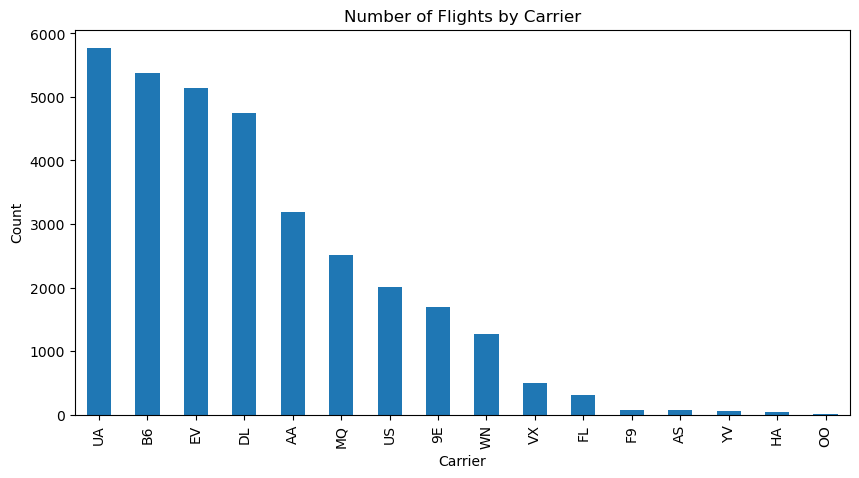

In [79]:
df['carrier'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title('Number of Flights by Carrier')
plt.xlabel('Carrier')
plt.ylabel('Count')
plt.show()

In [81]:
df[['dep_delay', 'arr_delay']].describe()

,dep_delay,arr_delay
count,32735.000000,32735.000000
mean,12.705147,7.100810
std,40.407426,44.687329
min,-21.000000,-73.000000
25%,-5.000000,-17.000000
50%,-2.000000,-5.000000
75%,11.000000,14.000000
max,1301.000000,1272.000000


In [83]:
df.sort_values(by='arr_delay', ascending=False)[['flight', 'carrier', 'dest', 'arr_delay']].head(10)

,flight,carrier,dest,arr_delay
30381,51,HA,HNL,1272
7277,1223,DL,SLC,847
18766,2019,AA,STL,802
26639,503,DL,SAN,769
32211,2042,DL,ATL,490
22254,4949,EV,GSO,444
20413,479,UA,IAH,435
44,1139,AA,DFW,434
9908,2226,WN,MDW,422
19939,3325,9E,DFW,421


In [85]:
carrier_delay = df.groupby('carrier')['arr_delay'].mean().sort_values(ascending=False)
carrier_delay

carrier
HA    28.088235
FL    19.553746
OO    16.666667
EV    16.210424
YV    15.094340
F9    12.478261
MQ    10.092142
B6     9.725632
WN     8.883426
9E     8.038325
UA     4.358232
VX     2.414487
US     1.803970
AA     1.398683
DL     0.906756
AS   -11.333333
Name: arr_delay, dtype: float64

In [117]:
df['arr_delay_sort']= df['arr_delay'].sort_values(ascending = False)
print(df['arr_delay_sort'].median())
print(df['arr_delay_sort'][20:].mean())

-5.0
7.097692190126853


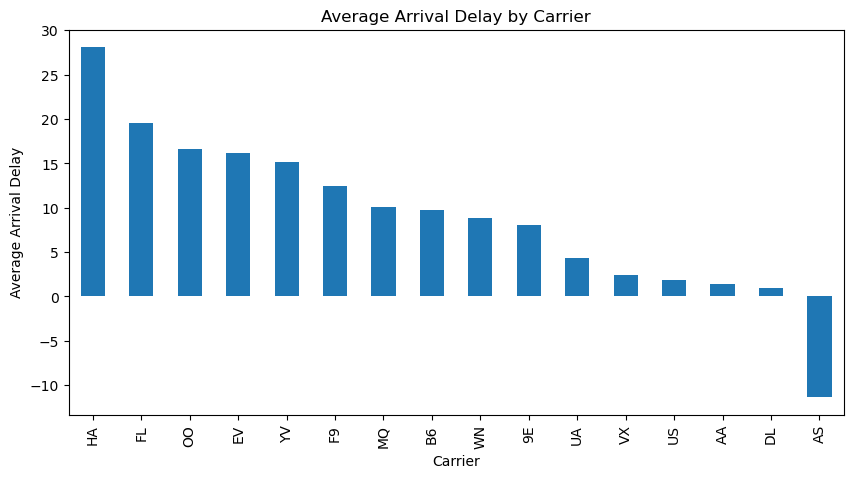

In [87]:
carrier_delay.plot(kind='bar', figsize=(10,5))
plt.title('Average Arrival Delay by Carrier')
plt.xlabel('Carrier')
plt.ylabel('Average Arrival Delay')
plt.show()

In [89]:
df[['dep_delay', 'arr_delay']].corr()

,dep_delay,arr_delay
dep_delay,1.000000,0.916062
arr_delay,0.916062,1.000000


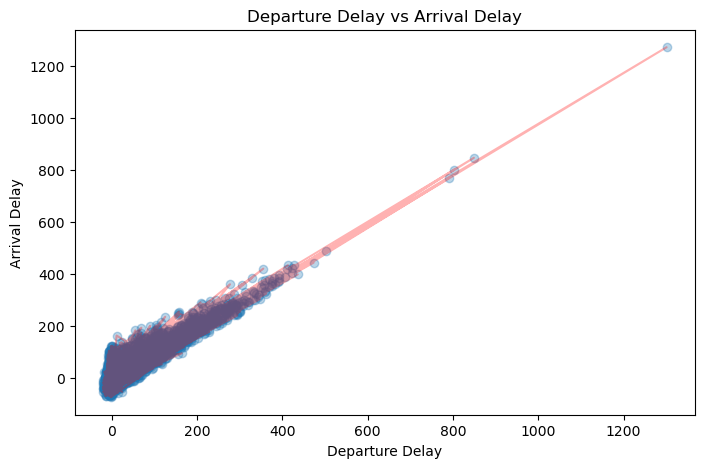

In [107]:
plt.figure(figsize=(8,5))
plt.scatter(df['dep_delay'], df['arr_delay'], alpha=0.3)
plt.plot(df['dep_delay'], df['arr_delay'], alpha=0.3,color = 'red')
plt.title('Departure Delay vs Arrival Delay')
plt.xlabel('Departure Delay')
plt.ylabel('Arrival Delay')
plt.show()

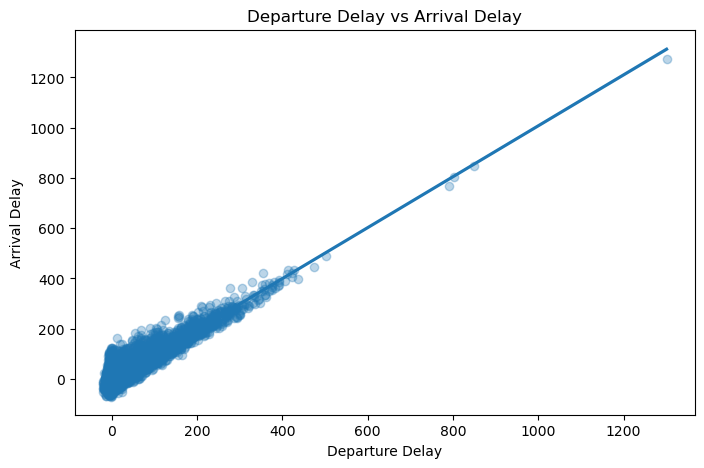

In [109]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.regplot(x=df['dep_delay'], y=df['arr_delay'], scatter_kws={'alpha':0.3})
plt.title('Departure Delay vs Arrival Delay')
plt.xlabel('Departure Delay')
plt.ylabel('Arrival Delay')
plt.show()

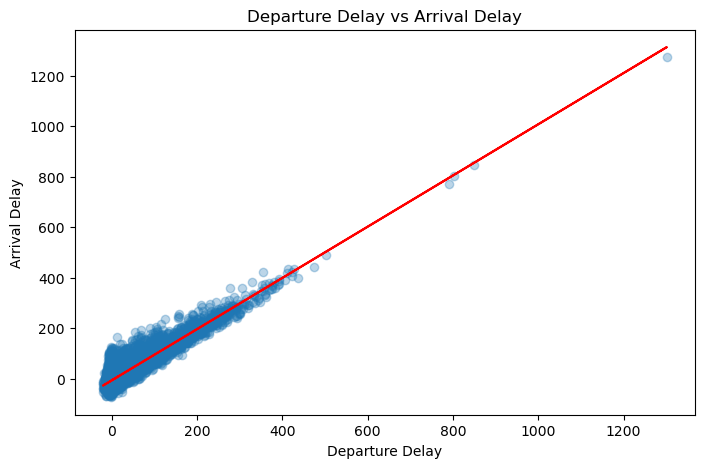

In [113]:
import numpy as np

# إزالة القيم الفارغة
clean_df = df[['dep_delay', 'arr_delay']].dropna()

x = clean_df['dep_delay']
y = clean_df['arr_delay']

# حساب خط الانحدار (درجة أولى)
m, b = np.polyfit(x, y, 1)

# رسم البيانات
plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.3)

# رسم خط الانحدار
plt.plot(x, m*x + b,color = "red")

plt.title('Departure Delay vs Arrival Delay')
plt.xlabel('Departure Delay')
plt.ylabel('Arrival Delay')
plt.show()

In [95]:
print(df.groupby('month')['arr_delay'].mean())
print("="*120)
print(df.groupby('origin')['arr_delay'].mean())
print("="*120)
print(df.groupby('carrier')['dep_delay'].mean())

month
1      6.834483
2      4.963255
3      6.316487
4     12.134124
5      3.645516
6     16.485359
7     16.148432
8      6.036111
9     -4.031332
10    -0.548890
11     1.249909
12    15.973490
Name: arr_delay, dtype: float64
origin
EWR    9.326820
JFK    5.983849
LGA    5.707063
Name: arr_delay, dtype: float64
carrier
9E    17.285967
AA     9.142409
AS     5.181818
B6    13.137091
DL     8.529573
EV    20.066122
F9    12.811594
FL    18.368078
HA    38.529412
MQ     9.617870
OO    22.000000
UA    12.725650
US     4.030769
VX    12.722334
WN    17.381443
YV    18.264151
Name: dep_delay, dtype: float64


## Key Insights

- Most flights were operated by a few major carriers.
- Arrival delay is strongly related to departure delay.
- Some carriers show higher average delays than others.
- Missing values exist mainly in delay-related columns and should be interpreted carefully.

## Conclusion
This analysis cleaned and explored the NYC Flights dataset to better understand flight delays and general flight patterns. The notebook showed how missing data, delays, and airline differences affect the dataset and provided a foundation for deeper analysis or future predictive modeling.